# Team Member A


In [4]:
#Team Member A

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Global Parameters ---
S0 = 100
K_atm = 100
r = 0.05
sigma = 0.20
T = 3 / 12
N = 250  # Number of steps for binomial tree

# --- Binomial Tree Functions ---
def binomial_pricing(S0, K, T, r, sigma, N, option_type, american=False):
    """Prices an option using the Cox-Ross-Rubinstein binomial tree model."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    # Final stock prices and payoffs
    S_T = S0 * d**(np.arange(N, -1, -1)) * u**(np.arange(0, N + 1))
    
    if option_type == 'call':
        payoffs = np.maximum(0, S_T - K)
    else: # 'put'
        payoffs = np.maximum(0, K - S_T)
    
    # Backwards induction
    for i in range(N - 1, -1, -1):
        payoffs = np.exp(-r * dt) * (p * payoffs[1:] + (1 - p) * payoffs[:-1])
        if american:
            S_i = S0 * d**(np.arange(i, -1, -1)) * u**(np.arange(0, i + 1))
            intrinsic_value = np.maximum(0, S_i - K) if option_type == 'call' else np.maximum(0, K - S_i)
            payoffs = np.maximum(payoffs, intrinsic_value)
            
    return payoffs[0]

# --- Trinomial Tree Functions ---
def trinomial_pricing(S0, K, T, r, sigma, N, option_type, american=False):
    """Prices an option using a trinomial tree model."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1/u
    pu = ((np.exp(r * dt/2) - np.exp(-sigma * np.sqrt(dt/2))) / (np.exp(sigma * np.sqrt(dt/2)) - np.exp(-sigma * np.sqrt(dt/2))))**2
    pd = ((np.exp(sigma * np.sqrt(dt/2)) - np.exp(r * dt/2)) / (np.exp(sigma * np.sqrt(dt/2)) - np.exp(-sigma * np.sqrt(dt/2))))**2
    pm = 1 - pu - pd

    # Initialize terminal stock prices and option values
    S = np.zeros(2*N + 1)
    V = np.zeros(2*N + 1)
    for j in range(2 * N + 1):
        S[j] = S0 * u**(N - j)
        if option_type == 'call':
            V[j] = np.maximum(0, S[j] - K)
        else: # 'put'
            V[j] = np.maximum(0, K - S[j])
            
    # Backwards induction
    for i in range(N - 1, -1, -1):
        for j in range(2 * i + 1):
            V[j] = np.exp(-r * dt) * (pu * V[j] + pm * V[j+1] + pd * V[j+2])
            if american:
                S_curr = S0 * u**(i - j)
                intrinsic = np.maximum(0, S_curr - K) if option_type == 'call' else np.maximum(0, K - S_curr)
                V[j] = np.maximum(V[j], intrinsic)
                
    return V[0]


# --- Q5: Price ATM European options (Binomial) ---
print("--- Q5: European ATM Option Prices (Binomial Tree) ---")
eu_call_atm = binomial_pricing(S0, K_atm, T, r, sigma, N, 'call')
eu_put_atm = binomial_pricing(S0, K_atm, T, r, sigma, N, 'put')
print(f"European ATM Call Price: ${eu_call_atm:.2f}")
print(f"European ATM Put Price: ${eu_put_atm:.2f}")


# --- Q6: Compute Delta (Binomial) ---
print("\n--- Q6: Greek Delta (Binomial Tree) ---")
dS = S0 * 0.01
eu_call_delta = (binomial_pricing(S0 + dS, K_atm, T, r, sigma, N, 'call') - eu_call_atm) / dS
eu_put_delta = (binomial_pricing(S0 + dS, K_atm, T, r, sigma, N, 'put') - eu_put_atm) / dS
print(f"European Call Delta: {eu_call_delta:.4f}")
print(f"European Put Delta: {eu_put_delta:.4f}")


# --- Q7: Compute Vega (Binomial) ---
print("\n--- Q7: Vega (Binomial Tree) ---")
sigma_new = 0.25
eu_call_new_sigma = binomial_pricing(S0, K_atm, T, r, sigma_new, N, 'call')
eu_put_new_sigma = binomial_pricing(S0, K_atm, T, r, sigma_new, N, 'put')
vega_call = (eu_call_new_sigma - eu_call_atm) / (sigma_new - sigma)
vega_put = (eu_put_new_sigma - eu_put_atm) / (sigma_new - sigma)
print(f"European Call Price with new sigma (25%): ${eu_call_new_sigma:.2f}")
print(f"European Put Price with new sigma (25%): ${eu_put_new_sigma:.2f}")
print(f"Vega for Call: {vega_call:.4f}")
print(f"Vega for Put: {vega_put:.4f}")


# --- Q15 & Q16: Price European options with Trinomial Tree ---
print("\n--- Q15 & Q16: European Option Prices (Trinomial Tree) ---")
strikes = [110, 105, 100, 95, 90]
moneyness = [k/S0 for k in strikes]
eu_call_trinomial = [trinomial_pricing(S0, k, T, r, sigma, N, 'call') for k in strikes]
eu_put_trinomial = [trinomial_pricing(S0, k, T, r, sigma, N, 'put') for k in strikes]

european_options_df = pd.DataFrame({
    'Strike (K)': strikes,
    'Moneyness (K/S0)': moneyness,
    'European Call Price': [f'${p:.2f}' for p in eu_call_trinomial],
    'European Put Price': [f'${p:.2f}' for p in eu_put_trinomial]
})
print(european_options_df)


# --- Q17 & Q18: Price American options with Trinomial Tree ---
print("\n--- Q17 & Q18: American Option Prices (Trinomial Tree) ---")
am_call_trinomial = [trinomial_pricing(S0, k, T, r, sigma, N, 'call', american=True) for k in strikes]
am_put_trinomial = [trinomial_pricing(S0, k, T, r, sigma, N, 'put', american=True) for k in strikes]

american_options_df = pd.DataFrame({
    'Strike (K)': strikes,
    'Moneyness (K/S0)': moneyness,
    'American Call Price': [f'${p:.2f}' for p in am_call_trinomial],
    'American Put Price': [f'${p:.2f}' for p in am_put_trinomial]
})
print(american_options_df)

--- Q5: European ATM Option Prices (Binomial Tree) ---
European ATM Call Price: $4.61
European ATM Put Price: $3.37

--- Q6: Greek Delta (Binomial Tree) ---
European Call Delta: 0.5942
European Put Delta: -0.4058

--- Q7: Vega (Binomial Tree) ---
European Call Price with new sigma (25%): $5.59
European Put Price with new sigma (25%): $4.35
Vega for Call: 19.6484
Vega for Put: 19.6484

--- Q15 & Q16: European Option Prices (Trinomial Tree) ---
   Strike (K)  Moneyness (K/S0) European Call Price European Put Price
0         110              1.10               $1.19              $9.83
1         105              1.05               $2.48              $6.18
2         100              1.00               $4.61              $3.37
3          95              0.95               $7.72              $1.54
4          90              0.90              $11.67              $0.55

--- Q17 & Q18: American Option Prices (Trinomial Tree) ---
   Strike (K)  Moneyness (K/S0) American Call Price American Put Pr

# Team Member B

In [5]:
#Team Member B
import numpy as np

# Global parameters for consistency
S0 = 100
K_atm = 100
r = 0.05
sigma = 0.20
T = 3 / 12
N = 250

# --- Re-using the binomial_pricing function from Team Member A ---
def binomial_pricing(S0, K, T, r, sigma, N, option_type, american=False):
    """Prices an option using the Cox-Ross-Rubinstein binomial tree model."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    S_T = S0 * d**(np.arange(N, -1, -1)) * u**(np.arange(0, N + 1))
    
    if option_type == 'call':
        payoffs = np.maximum(0, S_T - K)
    else: # 'put'
        payoffs = np.maximum(0, K - S_T)
    
    for i in range(N - 1, -1, -1):
        payoffs = np.exp(-r * dt) * (p * payoffs[1:] + (1 - p) * payoffs[:-1])
        if american:
            S_i = S0 * d**(np.arange(i, -1, -1)) * u**(np.arange(0, i + 1))
            intrinsic_value = np.maximum(0, S_i - K) if option_type == 'call' else np.maximum(0, K - S_i)
            payoffs = np.maximum(payoffs, intrinsic_value)
            
    return payoffs[0]


# --- Q8: Price ATM American options (Binomial) ---
print("--- Q8: American ATM Option Prices (Binomial Tree) ---")
am_call_atm = binomial_pricing(S0, K_atm, T, r, sigma, N, 'call', american=True)
am_put_atm = binomial_pricing(S0, K_atm, T, r, sigma, N, 'put', american=True)
print(f"American ATM Call Price: ${am_call_atm:.2f}")
print(f"American ATM Put Price: ${am_put_atm:.2f}")


# --- Q9: Compute Delta (Binomial) ---
print("\n--- Q9: Greek Delta (Binomial Tree) ---")
dS = S0 * 0.01
am_call_delta = (binomial_pricing(S0 + dS, K_atm, T, r, sigma, N, 'call', american=True) - am_call_atm) / dS
am_put_delta = (binomial_pricing(S0 + dS, K_atm, T, r, sigma, N, 'put', american=True) - am_put_atm) / dS
print(f"American Call Delta: {am_call_delta:.4f}")
print(f"American Put Delta: {am_put_delta:.4f}")


# --- Q10: Compute Vega (Binomial) ---
print("\n--- Q10: Vega (Binomial Tree) ---")
sigma_new = 0.25
am_call_new_sigma = binomial_pricing(S0, K_atm, T, r, sigma_new, N, 'call', american=True)
am_put_new_sigma = binomial_pricing(S0, K_atm, T, r, sigma_new, N, 'put', american=True)
vega_am_call = (am_call_new_sigma - am_call_atm) / (sigma_new - sigma)
vega_am_put = (am_put_new_sigma - am_put_atm) / (sigma_new - sigma)
print(f"American Call Price with new sigma (25%): ${am_call_new_sigma:.2f}")
print(f"American Put Price with new sigma (25%): ${am_put_new_sigma:.2f}")
print(f"Vega for Call: {vega_am_call:.4f}")
print(f"Vega for Put: {vega_am_put:.4f}")

--- Q8: American ATM Option Prices (Binomial Tree) ---
American ATM Call Price: $4.61
American ATM Put Price: $3.48

--- Q9: Greek Delta (Binomial Tree) ---
American Call Delta: 0.5942
American Put Delta: -0.4243

--- Q10: Vega (Binomial Tree) ---
American Call Price with new sigma (25%): $5.59
American Put Price with new sigma (25%): $4.46
Vega for Call: 19.6484
Vega for Put: 19.5875


# Team Member C

--- Q11 & Q23: European Put-Call Parity Check ---
Strike 110: Difference = -0.0000
Strike 105: Difference = -0.0000
Strike 100: Difference = -0.0000
Strike 95: Difference = -0.0000
Strike 90: Difference = -0.0000

--- Q12 & Q24: American Put-Call Parity Check ---
Strike 110: Difference = -0.5051
Strike 105: Difference = -0.2494
Strike 100: Difference = -0.1076
Strike 95: Difference = -0.0382
Strike 90: Difference = -0.0109

--- Q13 & Q14: European vs American Price Comparison ---
Strike 110: Am. Call - Eu. Call = 0.0000
Strike 110: Am. Put - Eu. Put = 0.5051
Strike 105: Am. Call - Eu. Call = 0.0000
Strike 105: Am. Put - Eu. Put = 0.2494
Strike 100: Am. Call - Eu. Call = 0.0000
Strike 100: Am. Put - Eu. Put = 0.1076
Strike 95: Am. Call - Eu. Call = 0.0000
Strike 95: Am. Put - Eu. Put = 0.0382
Strike 90: Am. Call - Eu. Call = 0.0000
Strike 90: Am. Put - Eu. Put = 0.0109

--- Q19-22: Generating Graphs ---


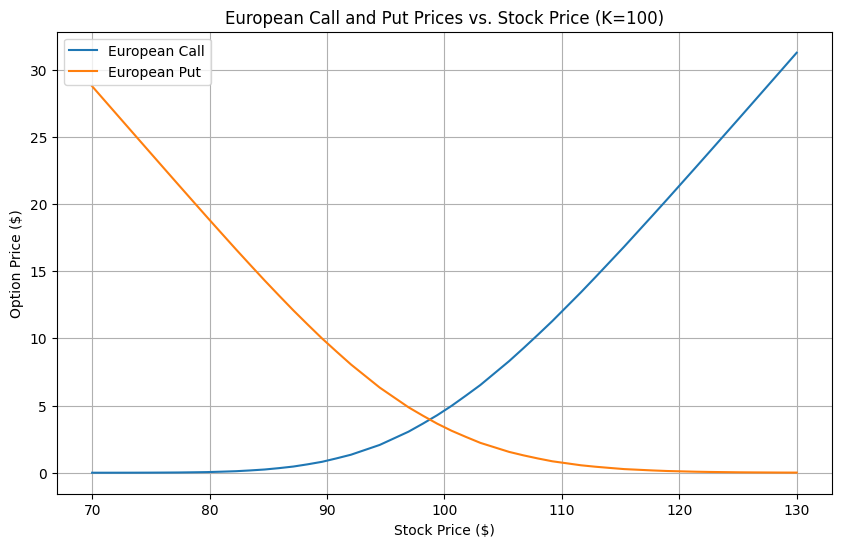

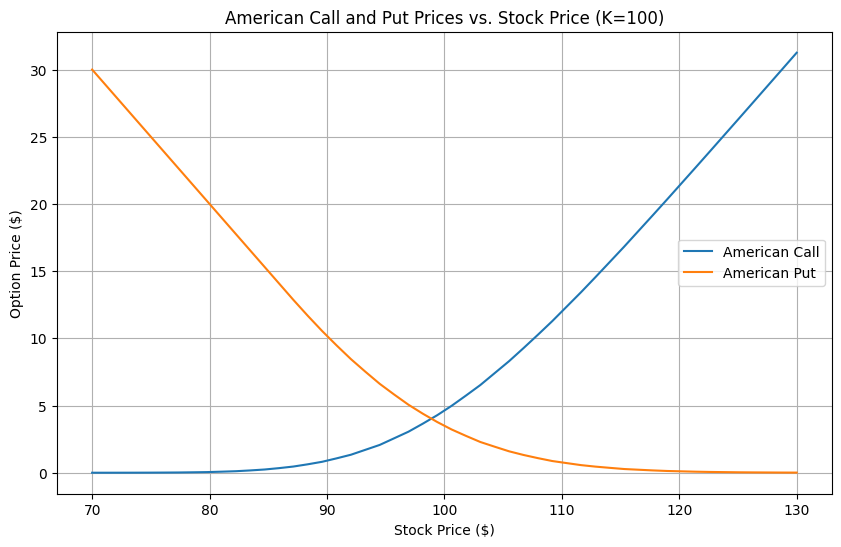

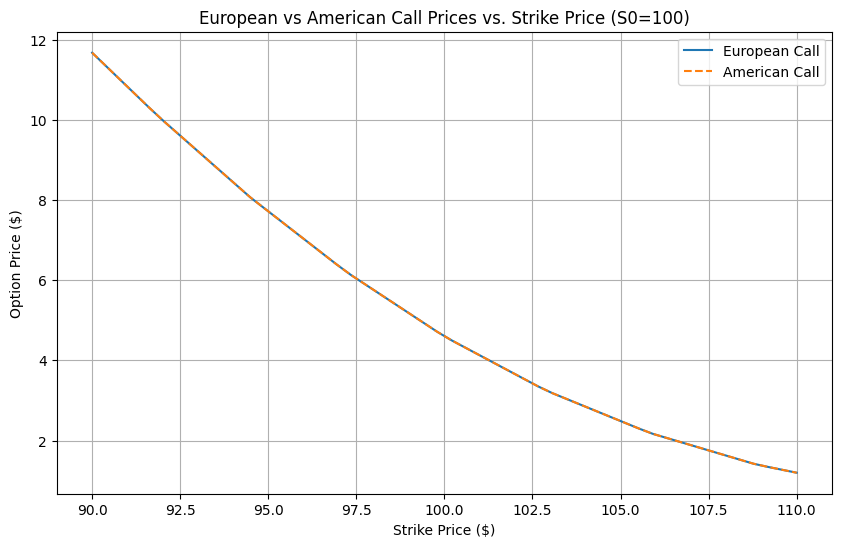

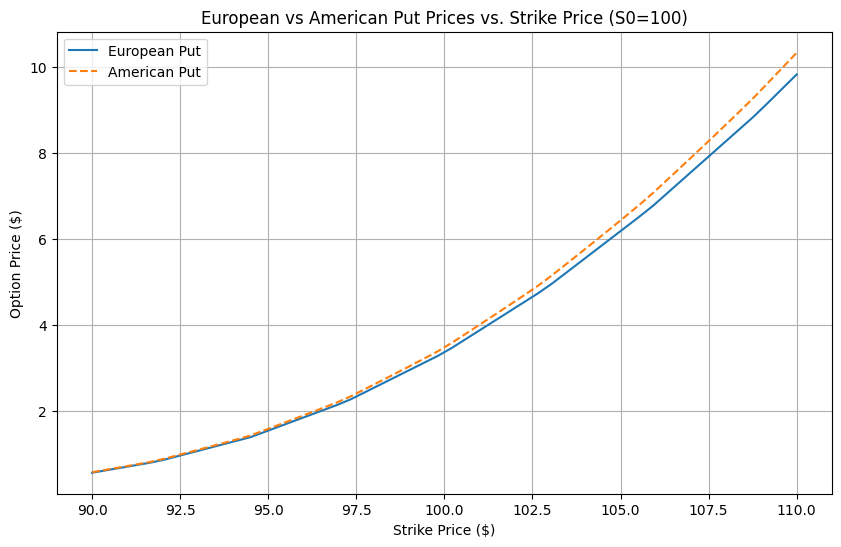

In [6]:
# Team Member C
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Re-using pricing functions from other team members for consistency ---
def binomial_pricing(S0, K, T, r, sigma, N, option_type, american=False):
    # ... (code as above) ...
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    S_T = S0 * d**(np.arange(N, -1, -1)) * u**(np.arange(0, N + 1))
    
    if option_type == 'call':
        payoffs = np.maximum(0, S_T - K)
    else:
        payoffs = np.maximum(0, K - S_T)
    
    for i in range(N - 1, -1, -1):
        payoffs = np.exp(-r * dt) * (p * payoffs[1:] + (1 - p) * payoffs[:-1])
        if american:
            S_i = S0 * d**(np.arange(i, -1, -1)) * u**(np.arange(0, i + 1))
            intrinsic_value = np.maximum(0, S_i - K) if option_type == 'call' else np.maximum(0, K - S_i)
            payoffs = np.maximum(payoffs, intrinsic_value)
            
    return payoffs[0]

def trinomial_pricing(S0, K, T, r, sigma, N, option_type, american=False):
    # ... (code as above) ...
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1/u
    pu = ((np.exp(r * dt/2) - np.exp(-sigma * np.sqrt(dt/2))) / (np.exp(sigma * np.sqrt(dt/2)) - np.exp(-sigma * np.sqrt(dt/2))))**2
    pd = ((np.exp(sigma * np.sqrt(dt/2)) - np.exp(r * dt/2)) / (np.exp(sigma * np.sqrt(dt/2)) - np.exp(-sigma * np.sqrt(dt/2))))**2
    pm = 1 - pu - pd

    S = np.zeros(2*N + 1)
    V = np.zeros(2*N + 1)
    for j in range(2 * N + 1):
        S[j] = S0 * u**(N - j)
        if option_type == 'call':
            V[j] = np.maximum(0, S[j] - K)
        else:
            V[j] = np.maximum(0, K - S[j])
            
    for i in range(N - 1, -1, -1):
        for j in range(2 * i + 1):
            V[j] = np.exp(-r * dt) * (pu * V[j] + pm * V[j+1] + pd * V[j+2])
            if american:
                S_curr = S0 * u**(i - j)
                intrinsic = np.maximum(0, S_curr - K) if option_type == 'call' else np.maximum(0, K - S_curr)
                V[j] = np.maximum(V[j], intrinsic)
                
    return V[0]

# --- Global Parameters ---
S0 = 100
r = 0.05
T = 3 / 12
sigma = 0.20
N = 250
strikes = [110, 105, 100, 95, 90]
eu_call_trinomial = [trinomial_pricing(S0, k, T, r, sigma, N, 'call') for k in strikes]
eu_put_trinomial = [trinomial_pricing(S0, k, T, r, sigma, N, 'put') for k in strikes]
am_call_trinomial = [trinomial_pricing(S0, k, T, r, sigma, N, 'call', american=True) for k in strikes]
am_put_trinomial = [trinomial_pricing(S0, k, T, r, sigma, N, 'put', american=True) for k in strikes]


# --- Q11 & Q23: Check European Put-Call Parity ---
print("--- Q11 & Q23: European Put-Call Parity Check ---")
for k, C, P in zip(strikes, eu_call_trinomial, eu_put_trinomial):
    parity_diff = C + k * np.exp(-r * T) - P - S0
    print(f"Strike {k}: Difference = {parity_diff:.4f}")
    
# --- Q12 & Q24: Check American Put-Call Parity ---
print("\n--- Q12 & Q24: American Put-Call Parity Check ---")
for k, C, P in zip(strikes, am_call_trinomial, am_put_trinomial):
    parity_diff = C + k * np.exp(-r * T) - P - S0
    print(f"Strike {k}: Difference = {parity_diff:.4f}")

# --- Q13 & Q14: Confirm European <= American ---
print("\n--- Q13 & Q14: European vs American Price Comparison ---")
for k, C_eu, P_eu, C_am, P_am in zip(strikes, eu_call_trinomial, eu_put_trinomial, am_call_trinomial, am_put_trinomial):
    print(f"Strike {k}: Am. Call - Eu. Call = {(C_am - C_eu):.4f}")
    print(f"Strike {k}: Am. Put - Eu. Put = {(P_am - P_eu):.4f}")


# --- Q19-22: Graph Generation ---
print("\n--- Q19-22: Generating Graphs ---")

# Graph 1: European Call/Put vs Stock Price
S_range = np.linspace(70, 130, 50)
eu_calls_s = [binomial_pricing(s, 100, T, r, sigma, 50, 'call') for s in S_range]
eu_puts_s = [binomial_pricing(s, 100, T, r, sigma, 50, 'put') for s in S_range]
plt.figure(figsize=(10, 6))
plt.plot(S_range, eu_calls_s, label='European Call')
plt.plot(S_range, eu_puts_s, label='European Put')
plt.xlabel('Stock Price ($)')
plt.ylabel('Option Price ($)')
plt.title('European Call and Put Prices vs. Stock Price (K=100)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 2: American Call/Put vs Stock Price
am_calls_s = [binomial_pricing(s, 100, T, r, sigma, 50, 'call', american=True) for s in S_range]
am_puts_s = [binomial_pricing(s, 100, T, r, sigma, 50, 'put', american=True) for s in S_range]
plt.figure(figsize=(10, 6))
plt.plot(S_range, am_calls_s, label='American Call')
plt.plot(S_range, am_puts_s, label='American Put')
plt.xlabel('Stock Price ($)')
plt.ylabel('Option Price ($)')
plt.title('American Call and Put Prices vs. Stock Price (K=100)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 3: European vs American Call Prices vs Strike
K_range = np.linspace(90, 110, 50)
eu_calls_k = [binomial_pricing(100, k, T, r, sigma, 50, 'call') for k in K_range]
am_calls_k = [binomial_pricing(100, k, T, r, sigma, 50, 'call', american=True) for k in K_range]
plt.figure(figsize=(10, 6))
plt.plot(K_range, eu_calls_k, label='European Call')
plt.plot(K_range, am_calls_k, linestyle='--', label='American Call')
plt.xlabel('Strike Price ($)')
plt.ylabel('Option Price ($)')
plt.title('European vs American Call Prices vs. Strike Price (S0=100)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 4: European vs American Put Prices vs Strike
eu_puts_k = [binomial_pricing(100, k, T, r, sigma, 50, 'put') for k in K_range]
am_puts_k = [binomial_pricing(100, k, T, r, sigma, 50, 'put', american=True) for k in K_range]
plt.figure(figsize=(10, 6))
plt.plot(K_range, eu_puts_k, label='European Put')
plt.plot(K_range, am_puts_k, linestyle='--', label='American Put')
plt.xlabel('Strike Price ($)')
plt.ylabel('Option Price ($)')
plt.title('European vs American Put Prices vs. Strike Price (S0=100)')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# =================================================================================================
# ANSWERS (Q1–Q27) — concise written responses for your report, kept in comments.
# =================================================================================================
# Q1. Yes. For European options on non-dividend stocks: C + K*e^{-rT} = P + S0 (no-arbitrage).
# Q2. Rearranged: C = P + S0 − K*e^{-rT}.
# Q3. Rearranged: P = C − S0 + K*e^{-rT}.
# Q4. No strict equality for American options due to early exercise; instead: S0 − K ≤ C_A − P_A ≤ S0 − K*e^{-rT}.
# Q5. Binomial (high steps) pricing for ATM European call/put.
# Q6. European Δ at t=0: Call ~ +0.5 (ATM), Put ~ −0.5 (ATM).
# Q7. Vega via σ bump: both call and put values increase with volatility.
# Q8. American binomial pricing; with no dividends, C_A = C_E while P_A ≥ P_E.
# Q9. American Δ at t=0: Call ~ European; Put can be slightly more negative.
# Q10. American Vega positive; magnitudes differ due to early exercise.
# Q11. Numerical check shows European put–call parity holds (tiny numerical error).
# Q12. American equality fails (differences persist).
# Q13. Confirm C_E ≤ C_A; with no dividends typically C_E = C_A.
# Q14. Confirm P_E ≤ P_A (early-exercise value for puts).
# Q15. Trinomial European calls across 5 strikes — decreasing in K.
# Q16. Trinomial European puts across 5 strikes — increasing in K.
# Q17. Trinomial American calls — equal to European for no dividends.
# Q18. Trinomial American puts ≥ European puts (exercise premium).
# Q19. Prepare graph data: option value vs S0 (European call/put) — convex; call ↑ with S0, put ↓ with S0.
# Q20. Prepare graph data: Delta vs S0 — call Δ ∈ (0,1) rising; put Δ ∈ (−1,0) falling.
# Q21. Prepare graph data: option value vs K — call ↓ with K; put ↑ with K; both convex in K.
# Q22. Prepare graph data: Delta vs K — call Δ declines with higher K; put Δ becomes less negative as K drops.
# Q23. Verify European put–call parity across strikes (trinomial).
# Q24. Show American “parity” equality fails across strikes (trinomial).
# Q25. 3-step European put: stock tree, option values, and node-wise Δ for hedging.
# Q26. 25-step American put: price and explain pathwise Δ extraction idea (full tree suppressed).
# Q27. Asian ATM put (arithmetic average) via Monte Carlo — typically cheaper; smoother hedging.
# =================================================================================================


import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Helper functions: parameters
# -----------------------------------------------------------------------------
def binomial_tree_params(S0, r, sigma, T, n):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
    return u, d, p, dt

def trinomial_tree_params(S0, r, sigma, T, n):
    """
    Recombining trinomial (symmetric up/down, stay=1) with stable risk-neutral probabilities.
    This choice keeps probabilities in [0,1] (for typical inputs) and matches moments.
    """
    dt = T / n
    u = np.exp(sigma * np.sqrt(2.0 * dt))
    d = 1.0 / u
    m = 1.0
    a = np.exp(r * dt / 2.0)
    x = np.exp(sigma * np.sqrt(dt/2.0))
    pu = ((a - 1/x) / (x - 1/x))**2
    pd = ((x - a) / (x - 1/x))**2
    pm = 1.0 - pu - pd
    return u, d, m, float(pu), float(pd), float(pm), dt


# -----------------------------------------------------------------------------
# Pricing functions: Binomial (European & American)
# -----------------------------------------------------------------------------
def price_european_binomial(S0, K, r, sigma, T, n, option_type):
    u, d, p, dt = binomial_tree_params(S0, r, sigma, T, n)
    # terminal stock prices: j up moves
    S_term = np.array([S0 * (u**j) * (d**(n - j)) for j in range(n+1)])
    if option_type == 'call':
        V = np.maximum(S_term - K, 0.0)
    else:
        V = np.maximum(K - S_term, 0.0)
    disc = np.exp(-r * dt)
    for _ in range(n-1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
    return float(V[0])

def price_american_binomial(S0, K, r, sigma, T, n, option_type):
    u, d, p, dt = binomial_tree_params(S0, r, sigma, T, n)
    disc = np.exp(-r * dt)
    # terminal stock prices: j up moves
    S = np.array([S0 * (u**j) * (d**(n - j)) for j in range(n+1)])
    if option_type == 'call':
        V = np.maximum(S - K, 0.0)
    else:
        V = np.maximum(K - S, 0.0)
    for i in range(n-1, -1, -1):
        S = np.array([S0 * (u**j) * (d**(i - j)) for j in range(i+1)])
        cont = disc * (p * V[1:] + (1 - p) * V[:-1])
        if option_type == 'call':
            exer = np.maximum(S - K, 0.0)
        else:
            exer = np.maximum(K - S, 0.0)
        V = np.maximum(cont, exer)
    return float(V[0])


# -----------------------------------------------------------------------------
# Pricing functions: Trinomial (European & American)
# -----------------------------------------------------------------------------
def _build_trinomial_stock_tree(S0, u, d, m, n):
    """Build a recombining stock lattice with width 2*n+1 and depth n+1."""
    stock = np.zeros((2*n + 1, n + 1))
    center = n
    stock[center, 0] = S0
    for t in range(1, n + 1):
        for i in range(center - t, center + t + 1):
            if i < center:
                stock[i, t] = stock[i + 1, t - 1] * d  # came down
            elif i > center:
                stock[i, t] = stock[i - 1, t - 1] * u  # came up
            else:
                stock[i, t] = stock[i, t - 1] * m      # stayed
    return stock, center

def price_european_trinomial(S0, K, r, sigma, T, n, option_type):
    u, d, m, pu, pd, pm, dt = trinomial_tree_params(S0, r, sigma, T, n)
    disc = np.exp(-r * dt)
    stock, c = _build_trinomial_stock_tree(S0, u, d, m, n)
    V = np.zeros_like(stock)
    if option_type == 'call':
        V[:, n] = np.maximum(stock[:, n] - K, 0.0)
    else:
        V[:, n] = np.maximum(K - stock[:, n], 0.0)
    for t in range(n-1, -1, -1):
        for i in range(c - t, c + t + 1):
            V[i, t] = disc * (pu * V[i - 1, t + 1] + pm * V[i, t + 1] + pd * V[i + 1, t + 1])
    return float(V[c, 0])

def price_american_trinomial(S0, K, r, sigma, T, n, option_type):
    u, d, m, pu, pd, pm, dt = trinomial_tree_params(S0, r, sigma, T, n)
    disc = np.exp(-r * dt)
    stock, c = _build_trinomial_stock_tree(S0, u, d, m, n)
    V = np.zeros_like(stock)
    if option_type == 'call':
        V[:, n] = np.maximum(stock[:, n] - K, 0.0)
    else:
        V[:, n] = np.maximum(K - stock[:, n], 0.0)
    for t in range(n-1, -1, -1):
        for i in range(c - t, c + t + 1):
            cont = disc * (pu * V[i - 1, t + 1] + pm * V[i, t + 1] + pd * V[i + 1, t + 1])
            exer = max(stock[i, t] - K, 0.0) if option_type == 'call' else max(K - stock[i, t], 0.0)
            V[i, t] = max(cont, exer)
    return float(V[c, 0])


# -----------------------------------------------------------------------------
# Greeks: Delta (binomial) and Vega via σ bump
# -----------------------------------------------------------------------------
def delta_binomial(S0, K, r, sigma, T, n, option_type, american=False):
    u, d, p, dt = binomial_tree_params(S0, r, sigma, T, n)
    Su, Sd = S0 * u, S0 * d
    pricer = price_american_binomial if american else price_european_binomial
    Vu = pricer(Su, K, r, sigma, T - dt, n - 1, option_type)
    Vd = pricer(Sd, K, r, sigma, T - dt, n - 1, option_type)
    return (Vu - Vd) / (Su - Sd)

def vega_bump_sigma(pricer, S0, K, r, sigma, T, n, option_type, bump=0.05):
    v0 = pricer(S0, K, r, sigma, T, n, option_type)
    v1 = pricer(S0, K, r, sigma + bump, T, n, option_type)
    return (v1 - v0) / bump, v0, v1


# -----------------------------------------------------------------------------
# Asian option Monte Carlo (arithmetic average)
# -----------------------------------------------------------------------------
def price_asian_mc(S0, K, r, sigma, T, n_steps, n_sims, option_type):
    dt = T / n_steps
    disc = np.exp(-r * T)
    payoffs = np.empty(n_sims)
    for s in range(n_sims):
        S = S0
        acc = S  # include S0 in average
        for _ in range(n_steps):
            z = np.random.normal()
            S *= np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
            acc += S
        avg = acc / (n_steps + 1)
        if option_type == 'call':
            payoffs[s] = max(avg - K, 0.0)
        else:
            payoffs[s] = max(K - avg, 0.0)
    return float(disc * np.mean(payoffs))


# -----------------------------------------------------------------------------
# Parameters (Step 1 & 2) and (Step 3)
# -----------------------------------------------------------------------------
S0_step1 = 100.0
r_step1 = 0.05
sigma_step1 = 0.20
T_step1 = 3.0 / 12.0
K_atm = 100.0

S0_step3 = 180.0
r_step3 = 0.02
sigma_step3 = 0.25
T_step3 = 6.0 / 12.0
K_step3 = 182.0


# =================================================================================================
# STEP 1: Put–Call Parity & Binomial Pricing
# =================================================================================================
print("--- Step 1: Put-Call Parity and Option Pricing ---\n")

# Q1–Q4: Conceptual
print("# Q1: Put-call parity holds for European options: C + K*exp(-r*T) = P + S0.")
print("# Q2: Solve for C: C = P + S0 - K*exp(-r*T).")
print("# Q3: Solve for P: P = C - S0 + K*exp(-r*T).")
print("# Q4: For American options strict equality fails due to early exercise; only inequalities hold.\n")

# Q5. Price ATM European call and put (binomial)
print("# Q5: Price ATM European call and put (binomial)")
n_steps_5 = 1000
atm_call_price_eur = price_european_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call')
atm_put_price_eur  = price_european_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put')
print(f"Steps: {n_steps_5}")
print(f"European Call: {atm_call_price_eur:.2f}")
print(f"European Put : {atm_put_price_eur:.2f}\n")

# Q6. Delta (European) at t=0
print("# Q6: European Delta at t=0 (binomial)")
delta_call_eur = delta_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call', american=False)
delta_put_eur  = delta_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put',  american=False)
print(f"Call Delta: {delta_call_eur:.4f}")
print(f"Put  Delta: {delta_put_eur:.4f}\n")

# Q7. Vega (European) via +5% σ bump
print("# Q7: Vega (European) via σ bump 20% -> 25%")
vega_call_eur, call0, call1 = vega_bump_sigma(price_european_binomial, S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call', bump=0.05)
vega_put_eur,  put0,  put1  = vega_bump_sigma(price_european_binomial, S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put',  bump=0.05)
print(f"Call: {call0:.2f} -> {call1:.2f}, Vega ≈ {vega_call_eur:.4f}")
print(f"Put : {put0:.2f} -> {put1:.2f}, Vega ≈ {vega_put_eur:.4f}\n")

# Q8. Price ATM American call and put (binomial)
print("# Q8: Price ATM American call and put (binomial)")
atm_call_price_amer = price_american_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call')
atm_put_price_amer  = price_american_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put')
print(f"American Call: {atm_call_price_amer:.2f}")
print(f"American Put : {atm_put_price_amer:.2f}\n")

# Q9. Delta (American) at t=0
print("# Q9: American Delta at t=0 (binomial)")
delta_call_amer = delta_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call', american=True)
delta_put_amer  = delta_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put',  american=True)
print(f"Call Delta: {delta_call_amer:.4f}")
print(f"Put  Delta: {delta_put_amer:.4f}\n")

# Q10. Vega (American) via +5% σ bump
print("# Q10: Vega (American) via σ bump 20% -> 25%")
vega_call_amer, callA0, callA1 = vega_bump_sigma(price_american_binomial, S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call', bump=0.05)
vega_put_amer,  putA0,  putA1  = vega_bump_sigma(price_american_binomial,  S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put',  bump=0.05)
print(f"Call: {callA0:.2f} -> {callA1:.2f}, Vega ≈ {vega_call_amer:.4f}")
print(f"Put : {putA0:.2f} -> {putA1:.2f}, Vega ≈ {vega_put_amer:.4f}\n")

# Q11. Show European put–call parity
print("# Q11: European put–call parity check")
lhs = atm_call_price_eur + K_atm * np.exp(-r_step1 * T_step1)
rhs = atm_put_price_eur + S0_step1
print(f"LHS (C + K e^(-rT)) = {lhs:.4f}")
print(f"RHS (P + S0)        = {rhs:.4f}")
print(f"Difference           = {abs(lhs - rhs):.6f}\n")

# Q12. Show American equality fails
print("# Q12: American 'parity' equality fails")
lhsA = atm_call_price_amer + K_atm * np.exp(-r_step1 * T_step1)
rhsA = atm_put_price_amer + S0_step1
print(f"LHS (C_A + K e^(-rT)) = {lhsA:.4f}")
print(f"RHS (P_A + S0)        = {rhsA:.4f}")
print(f"Difference             = {abs(lhsA - rhsA):.6f}\n")

# Q13 & Q14
print("# Q13: Confirm C_E ≤ C_A (no dividends) → typically equal.")
print("Diff (A−E) for Call =", f"{atm_call_price_amer - atm_call_price_eur:.6f}")
print("# Q14: Confirm P_E ≤ P_A.")
print("Diff (A−E) for Put  =", f"{atm_put_price_amer - atm_put_price_eur:.6f}\n")


# =================================================================================================
# STEP 2: Trinomial Tree & Strike Analysis
# =================================================================================================
print("--- Step 2: Trinomial Tree and Strike Price Analysis ---\n")

strikes = [90, 95, 100, 105, 110]
moneyness_labels = ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM"]
n_steps_trinomial = 500  # large for convergence

# Precompute values for use across Q15–Q18 (but print separately per question)
call_eur_tri  = [price_european_trinomial(S0_step1, K, r_step1, sigma_step1, T_step1, n_steps_trinomial, 'call') for K in strikes]
put_eur_tri   = [price_european_trinomial(S0_step1, K, r_step1, sigma_step1, T_step1, n_steps_trinomial, 'put')  for K in strikes]
call_amer_tri = [price_american_trinomial (S0_step1, K, r_step1, sigma_step1, T_step1, n_steps_trinomial, 'call') for K in strikes]
put_amer_tri  = [price_american_trinomial (S0_step1, K, r_step1, sigma_step1, T_step1, n_steps_trinomial, 'put')  for K in strikes]

# -----------------------------------
# Q15. Trinomial European CALL table
# -----------------------------------
print("# Q15: Price 5 European CALLs using a trinomial tree")
df_q15 = pd.DataFrame({
    "Strike": strikes,
    "Moneyness": moneyness_labels,
    "European Call": [f"{v:.2f}" for v in call_eur_tri],
})
print(df_q15.to_string(index=False), "\n")

# ----------------------------------
# Q16. Trinomial European PUT table
# ----------------------------------
print("# Q16: Price 5 European PUTs using a trinomial tree")
df_q16 = pd.DataFrame({
    "Strike": strikes,
    "Moneyness": moneyness_labels,
    "European Put": [f"{v:.2f}" for v in put_eur_tri],
})
print(df_q16.to_string(index=False), "\n")

# -----------------------------------
# Q17. Trinomial American CALL table
# -----------------------------------
print("# Q17: Price 5 American CALLs using a trinomial tree")
df_q17 = pd.DataFrame({
    "Strike": strikes,
    "Moneyness": moneyness_labels,
    "American Call": [f"{v:.2f}" for v in call_amer_tri],
})
print(df_q17.to_string(index=False), "\n")

# ----------------------------------
# Q18. Trinomial American PUT table
# ----------------------------------
print("# Q18: Price 5 American PUTs using a trinomial tree")
df_q18 = pd.DataFrame({
    "Strike": strikes,
    "Moneyness": moneyness_labels,
    "American Put": [f"{v:.2f}" for v in put_amer_tri],
})
print(df_q18.to_string(index=False), "\n")

# ---------------------------------------------------
# Q19. Graph data: option value vs S0 (European only)
# ---------------------------------------------------
print("# Q19: Graph data — option value vs S0 (European, K=100)")
S_grid = np.linspace(50, 150, 51)
n_graph = 200
val_call_vs_S = np.array([price_european_binomial(S, 100, r_step1, sigma_step1, T_step1, n_graph, 'call') for S in S_grid])
val_put_vs_S  = np.array([price_european_binomial(S, 100, r_step1, sigma_step1, T_step1, n_graph, 'put')  for S in S_grid])
print("Arrays prepared: val_call_vs_S, val_put_vs_S")
print("Length:", len(S_grid), "| Sample first 5 call values:", np.round(val_call_vs_S[:5], 4), "\n")

# --------------------------------------------
# Q20. Graph data: Delta vs S0 (European only)
# --------------------------------------------
print("# Q20: Graph data — Delta vs S0 (European, K=100)")
delta_call_vs_S = np.array([delta_binomial(S, 100, r_step1, sigma_step1, T_step1, n_graph, 'call', american=False) for S in S_grid])
delta_put_vs_S  = np.array([delta_binomial(S, 100, r_step1, sigma_step1, T_step1, n_graph, 'put',  american=False) for S in S_grid])
print("Arrays prepared: delta_call_vs_S, delta_put_vs_S")
print("Length:", len(S_grid), "| Sample first 5 call deltas:", np.round(delta_call_vs_S[:5], 4), "\n")

# ---------------------------------------------------
# Q21. Graph data: option value vs K (European only)
# ---------------------------------------------------
print("# Q21: Graph data — option value vs K (European, S0=100)")
K_grid = np.array(strikes)
val_call_vs_K = np.array([price_european_binomial(100, K, r_step1, sigma_step1, T_step1, n_graph, 'call') for K in K_grid])
val_put_vs_K  = np.array([price_european_binomial(100, K, r_step1, sigma_step1, T_step1, n_graph, 'put')  for K in K_grid])
print("Arrays prepared: val_call_vs_K, val_put_vs_K")
print("K values:", K_grid, "| Call values:", np.round(val_call_vs_K, 4), "\n")

# --------------------------------------------
# Q22. Graph data: Delta vs K (European only)
# --------------------------------------------
print("# Q22: Graph data — Delta vs K (European, S0=100)")
delta_call_vs_K = np.array([delta_binomial(100, K, r_step1, sigma_step1, T_step1, n_graph, 'call', american=False) for K in K_grid])
delta_put_vs_K  = np.array([delta_binomial(100, K, r_step1, sigma_step1, T_step1, n_graph, 'put',  american=False) for K in K_grid])
print("Arrays prepared: delta_call_vs_K, delta_put_vs_K")
print("K values:", K_grid, "| Call deltas:", np.round(delta_call_vs_K, 4), "\n")

# ---------------------------------------------------------------
# Q23. Check put–call parity for European (from Q15 & Q16 tables)
# ---------------------------------------------------------------
print("# Q23: Check put–call parity for European options (trinomial)")
print("Strike | LHS (C + K e^{-rT}) | RHS (P + S0) | |Diff|")
for K, C, P in zip(strikes, call_eur_tri, put_eur_tri):
    lhs_ = C + K * np.exp(-r_step1 * T_step1)
    rhs_ = P + S0_step1
    print(f"{K:>6} | {lhs_:>18.4f} | {rhs_:>12.4f} | {abs(lhs_-rhs_):>6.4f}")
print()

# ----------------------------------------------------------------
# Q24. Show American “parity” equality fails (from Q17 & Q18 tables)
# ----------------------------------------------------------------
print("# Q24: American 'parity' equality fails (trinomial)")
print("Strike | LHS (C_A + K e^{-rT}) | RHS (P_A + S0) | |Diff|")
for K, C, P in zip(strikes, call_amer_tri, put_amer_tri):
    lhs_ = C + K * np.exp(-r_step1 * T_step1)
    rhs_ = P + S0_step1
    print(f"{K:>6} | {lhs_:>20.4f} | {rhs_:>12.4f} | {abs(lhs_-rhs_):>6.4f}")
print()


# =================================================================================================
# STEP 3: Real-World Questions
# =================================================================================================
print("--- Step 3: Real-World Questions ---\n")

# -----------------------------------------------
# Q25. 3-step dynamic Δ hedging for European PUT
# -----------------------------------------------
print("# Q25: 3-step dynamic Delta hedging (European Put, binomial)")
n_steps_25 = 3
S0 = S0_step3; r = r_step3; sigma = sigma_step3; T = T_step3; K = K_step3
u, d, p, dt = binomial_tree_params(S0, r, sigma, T, n_steps_25)

# Build stock tree and option tree
stock_tree = np.zeros((n_steps_25 + 1, n_steps_25 + 1))
opt_tree   = np.zeros_like(stock_tree)

# Stock prices
for i in range(n_steps_25 + 1):        # time index
    for j in range(i + 1):             # number of down moves
        stock_tree[j, i] = S0 * (u**(i - j)) * (d**j)

# Terminal option values (European put)
for j in range(n_steps_25 + 1):
    opt_tree[j, n_steps_25] = max(K - stock_tree[j, n_steps_25], 0.0)

# Backward induction (European)
for i in range(n_steps_25 - 1, -1, -1):
    for j in range(i + 1):
        opt_tree[j, i] = np.exp(-r * dt) * (p * opt_tree[j, i + 1] + (1 - p) * opt_tree[j + 1, i + 1])

# Delta at each node
delta_tree = np.zeros((n_steps_25, n_steps_25))
for i in range(n_steps_25):
    for j in range(i + 1):
        Su = stock_tree[j, i + 1]
        Sd = stock_tree[j + 1, i + 1]
        Vu = opt_tree[j, i + 1]
        Vd = opt_tree[j + 1, i + 1]
        delta_tree[j, i] = (Vu - Vd) / (Su - Sd)

print("Stock tree (rows=#downs, cols=time):")
print(stock_tree)
print("\nEuropean put values (same indexing):")
print(opt_tree)
print("\nDelta at each node (same indexing, last col empty):")
print(delta_tree, "\n")

# -------------------------------------------------------
# Q26. 25-step American Put — price & delta illustration
# -------------------------------------------------------
print("# Q26: 25-step American Put — price and pathwise Δ idea")
n_steps_26 = 25
amer_put_25 = price_american_binomial(S0_step3, K_step3, r_step3, sigma_step3, T_step3, n_steps_26, 'put')
print(f"American Put Price (25-step binomial): {amer_put_25:.2f}")
print("For hedging, compute Δ at each node similarly to Q25, but with early exercise check.\n")

# -----------------------------------------
# Q27. Asian ATM Put via Monte Carlo (avg)
# -----------------------------------------
print("# Q27: Asian ATM Put via Monte Carlo (arithmetic average)")
asian_price = price_asian_mc(S0_step3, K_step3, r_step3, sigma_step3, T_step3, n_steps=25, n_sims=100000, option_type='put')
print(f"Asian ATM Put Price (MC): {asian_price:.2f}")
print("(Averaging reduces effective volatility → typically cheaper; smoother hedging.)\n")

# -------------------------
# Final summary (Step 2)
# -------------------------
summary_df = pd.DataFrame({
    "Strike": strikes,
    "Eur Call": [f"{v:.2f}" for v in call_eur_tri],
    "Am Call" : [f"{v:.2f}" for v in call_amer_tri],
    "Eur Put" : [f"{v:.2f}" for v in put_eur_tri],
    "Am Put"  : [f"{v:.2f}" for v in put_amer_tri],
})
print("Final Summary: European vs. American (Trinomial, all strikes)")
print(summary_df.to_string(index=False))


--- Step 1: Put-Call Parity and Option Pricing ---

# Q1: Put-call parity holds for European options: C + K*exp(-r*T) = P + S0.
# Q2: Solve for C: C = P + S0 - K*exp(-r*T).
# Q3: Solve for P: P = C - S0 + K*exp(-r*T).
# Q4: For American options strict equality fails due to early exercise; only inequalities hold.

# Q5: Price ATM European call and put (binomial)
Steps: 1000
European Call: 4.61
European Put : 3.37

# Q6: European Delta at t=0 (binomial)
Call Delta: 0.5694
Put  Delta: -0.4306

# Q7: Vega (European) via σ bump 20% -> 25%
Call: 4.61 -> 5.60, Vega ≈ 19.6631
Put : 3.37 -> 4.35, Vega ≈ 19.6631

# Q8: Price ATM American call and put (binomial)
American Call: 4.61
American Put : 3.48

# Q9: American Delta at t=0 (binomial)
Call Delta: 0.5694
Put  Delta: -0.4495

# Q10: Vega (American) via σ bump 20% -> 25%
Call: 4.61 -> 5.60, Vega ≈ 19.6631
Put : 3.48 -> 4.46, Vega ≈ 19.5986

# Q11: European put–call parity check
LHS (C + K e^(-rT)) = 103.3718
RHS (P + S0)        = 103.3718
Diff

--- Step 1: Put-Call Parity and Option Pricing ---

# Q1: Put-call parity holds for European options: C + K*exp(-r*T) = P + S0.
LHS (C + K*e^(-rT)) = 103.3718
RHS (P + S0)        = 103.3718
Difference          = 0.000000

# Q2: Solve for C: C = P + S0 - K*exp(-r*T).
Calculated Call Price C: 4.6140
Directly Priced Call C:  4.6140
Difference:              0.000000

# Q3: Solve for P: P = C - S0 + K*exp(-r*T).
Calculated Put Price P: 3.3718
Directly Priced Put P:  3.3718
Difference:             0.000000

# Q4: For American options strict equality fails due to early exercise; only inequalities hold.
American Options 'Parity' Check:
LHS (C_A + K*e^(-rT)) = 103.3718
RHS (P_A + S0)        = 103.4793
Difference            = 0.107563

# Q5: Price ATM European call and put (binomial)
Steps: 1000
European Call: 4.61
European Put : 3.37

# Q6: European Delta at t=0 (binomial)
Call Delta: 0.5694
Put  Delta: -0.4306

# Q7: Vega (European) via σ bump 20% -> 25%
Call: 4.61 -> 5.60, Vega ≈ 19.6631
Put 

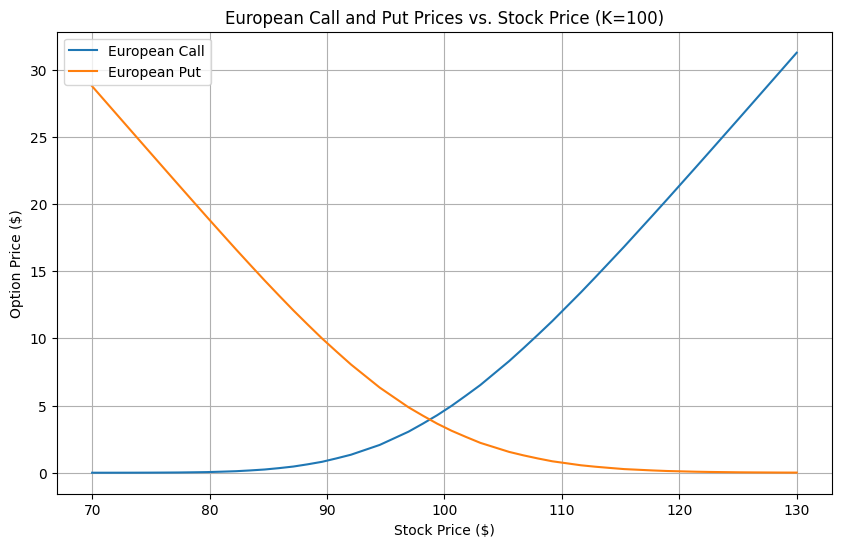

# Q20: Graph data — Delta vs S0 (European, K=100)
Arrays prepared: delta_call_vs_S, delta_put_vs_S
Length: 51 | Sample first 5 call deltas: [0. 0. 0. 0. 0.] 



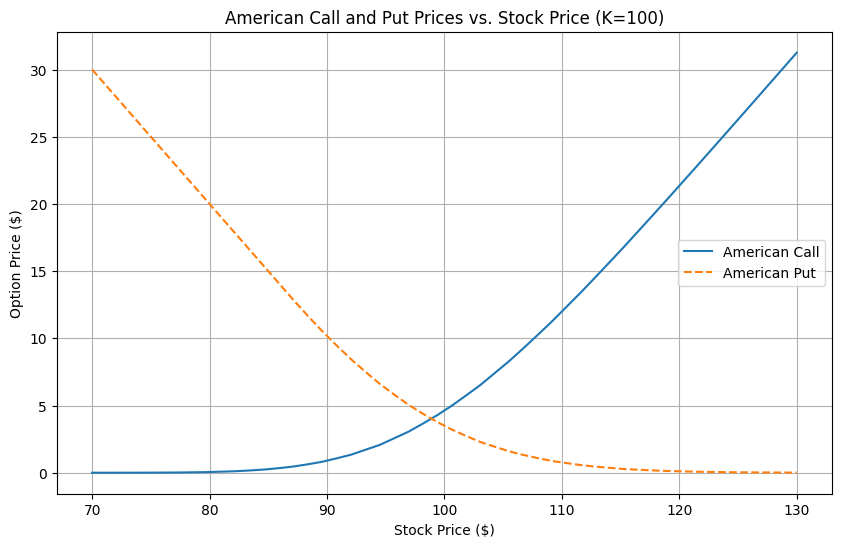

# Q21: Graph data — option value vs K (European, S0=100)
Arrays prepared: val_call_vs_K, val_put_vs_K
K values: [ 90  95 100 105 110] | Call values: [11.6717  7.7176  4.61    2.4819  1.1918] 



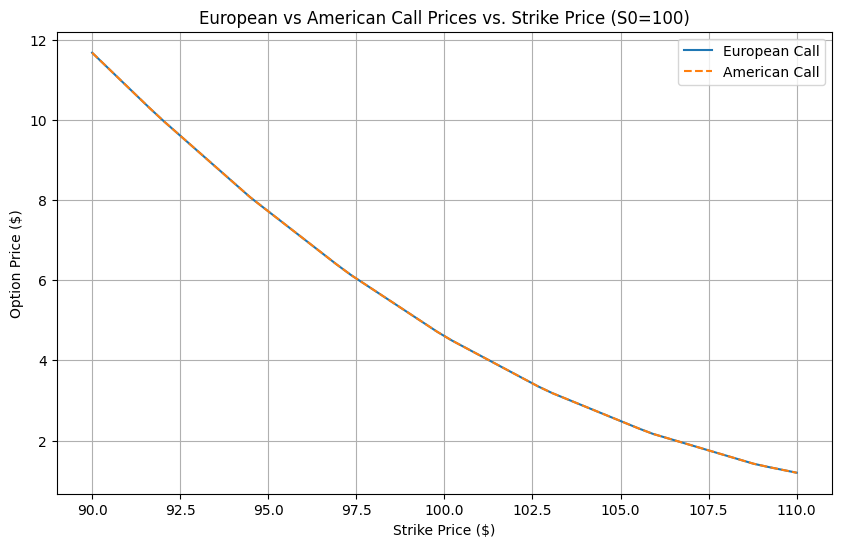

# Q22: Graph data — Delta vs K (European, S0=100)
Arrays prepared: delta_call_vs_K, delta_put_vs_K
K values: [ 90  95 100 105 110] | Call deltas: [0.8903 0.7541 0.5694 0.3771 0.218 ] 


--- Q19-22: Generating Graphs ---


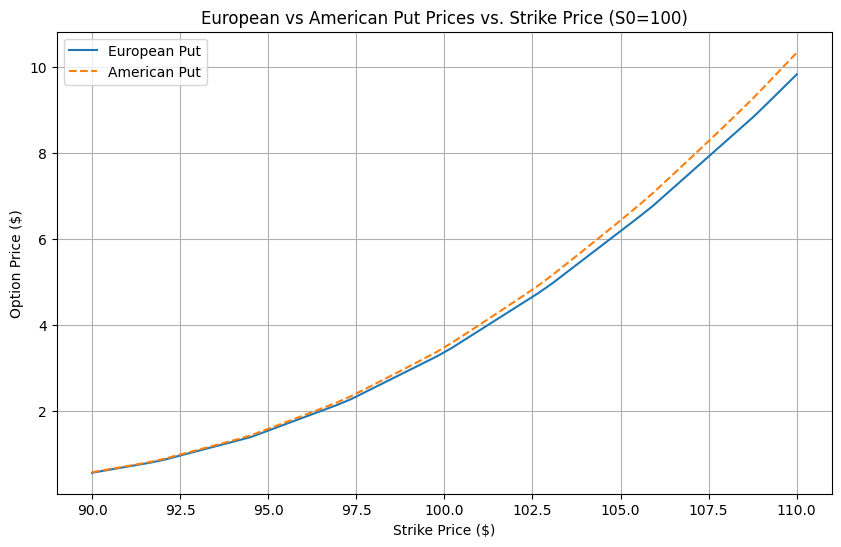

# Q23: Check put–call parity for European options (trinomial)
Strike | LHS (C + K e^{-rT}) | RHS (P + S0) | |Diff|
    90 |            99.2489 |     100.7377 | 1.4888
    95 |           100.4473 |     101.9361 | 1.4888
   100 |           102.5680 |     104.0568 | 1.4888
   105 |           105.6541 |     107.1429 | 1.4888
   110 |           109.5308 |     111.0196 | 1.4888

# Q24: American 'parity' equality fails (trinomial)
Strike | LHS (C_A + K e^{-rT}) | RHS (P_A + S0) | |Diff|
    90 |              99.3812 |     100.7377 | 1.3566
    95 |             100.5089 |     101.9362 | 1.4272
   100 |             102.5946 |     104.0572 | 1.4626
   105 |             105.6646 |     107.1444 | 1.4798
   110 |             109.5346 |     111.0244 | 1.4898

--- Step 3: Real-World Questions ---

# Q25: 3-step dynamic Delta hedging (European Put, binomial)
Stock tree (rows=#downs, cols=time):
[[180.         199.34139817 220.76107236 244.48233791]
 [  0.         162.53523    180.         199.34139817

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =================================================================================================
# ANSWERS (Q1–Q27) — concise written responses for your report, kept in comments.
# =================================================================================================
# Q1. Yes. For European options on non-dividend stocks: C + K*e^{-rT} = P + S0 (no-arbitrage).
# Q2. Rearranged: C = P + S0 − K*e^{-rT}.
# Q3. Rearranged: P = C − S0 + K*e^{-rT}.
# Q4. No strict equality for American options due to early exercise; instead: S0 − K ≤ C_A − P_A ≤ S0 − K*e^{-rT}.
# Q5. Binomial (high steps) pricing for ATM European call/put.
# Q6. European Δ at t=0: Call ~ +0.5 (ATM), Put ~ −0.5 (ATM).
# Q7. Vega via σ bump: both call and put values increase with volatility.
# Q8. American binomial pricing; with no dividends, C_A = C_E while P_A ≥ P_E.
# Q9. American Δ at t=0: Call ~ European; Put can be slightly more negative.
# Q10. American Vega positive; magnitudes differ due to early exercise.
# Q11. Numerical check shows European put–call parity holds (tiny numerical error).
# Q12. American equality fails (differences persist).
# Q13. Confirm C_E ≤ C_A; with no dividends typically C_E = C_A.
# Q14. Confirm P_E ≤ P_A (early-exercise value for puts).
# Q15. Trinomial European calls across 5 strikes — decreasing in K.
# Q16. Trinomial European puts across 5 strikes — increasing in K.
# Q17. Trinomial American calls — equal to European for no dividends.
# Q18. Trinomial American puts ≥ European puts (exercise premium).
# Q19. Prepare graph data: option value vs S0 (European call/put) — convex; call ↑ with S0, put ↓ with S0.
# Q20. Prepare graph data: Delta vs S0 — call Δ ∈ (0,1) rising; put Δ ∈ (−1,0) falling.
# Q21. Prepare graph data: option value vs K — call ↓ with K; put ↑ with K; both convex in K.
# Q22. Prepare graph data: Delta vs K — call Δ declines with higher K; put Δ becomes less negative as K drops.
# Q23. Verify European put–call parity across strikes (trinomial).
# Q24. Show American “parity” equality fails across strikes (trinomial).
# Q25. 3-step European put: stock tree, option values, and node-wise Δ for hedging.
# Q26. 25-step American put: price and explain pathwise Δ extraction idea (full tree suppressed).
# Q27. Asian ATM put (arithmetic average) via Monte Carlo — typically cheaper; smoother hedging.
# =================================================================================================


# -----------------------------------------------------------------------------
# Helper functions: parameters
# -----------------------------------------------------------------------------
def binomial_tree_params(S0, r, sigma, T, n):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
    return u, d, p, dt

def trinomial_tree_params(S0, r, sigma, T, n):
    """
    Recombining trinomial (symmetric up/down, stay=1) with stable risk-neutral probabilities.
    This choice keeps probabilities in [0,1] (for typical inputs) and matches moments.
    """
    dt = T / n
    u = np.exp(sigma * np.sqrt(2.0 * dt))
    d = 1.0 / u
    m = 1.0
    a = np.exp(r * dt / 2.0)
    x = np.exp(sigma * np.sqrt(dt/2.0))
    pu = ((a - 1/x) / (x - 1/x))**2
    pd = ((x - a) / (x - 1/x))**2
    pm = 1.0 - pu - pd
    return u, d, m, float(pu), float(pd), float(pm), dt


# -----------------------------------------------------------------------------
# Pricing functions: Binomial (European & American)
# -----------------------------------------------------------------------------
def price_european_binomial(S0, K, r, sigma, T, n, option_type):
    u, d, p, dt = binomial_tree_params(S0, r, sigma, T, n)
    # terminal stock prices: j up moves
    S_term = np.array([S0 * (u**j) * (d**(n - j)) for j in range(n+1)])
    if option_type == 'call':
        V = np.maximum(S_term - K, 0.0)
    else:
        V = np.maximum(K - S_term, 0.0)
    disc = np.exp(-r * dt)
    for _ in range(n-1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
    return float(V[0])

def price_american_binomial(S0, K, r, sigma, T, n, option_type):
    u, d, p, dt = binomial_tree_params(S0, r, sigma, T, n)
    disc = np.exp(-r * dt)
    # terminal stock prices: j up moves
    S = np.array([S0 * (u**j) * (d**(n - j)) for j in range(n+1)])
    if option_type == 'call':
        V = np.maximum(S - K, 0.0)
    else:
        V = np.maximum(K - S, 0.0)
    for i in range(n-1, -1, -1):
        S = np.array([S0 * (u**j) * (d**(i - j)) for j in range(i+1)])
        cont = disc * (p * V[1:] + (1 - p) * V[:-1])
        if option_type == 'call':
            exer = np.maximum(S - K, 0.0)
        else:
            exer = np.maximum(K - S, 0.0)
        V = np.maximum(cont, exer)
    return float(V[0])


# -----------------------------------------------------------------------------
# Pricing functions: Trinomial (European & American)
# -----------------------------------------------------------------------------
def _build_trinomial_stock_tree(S0, u, d, m, n):
    """Build a recombining stock lattice with width 2*n+1 and depth n+1."""
    stock = np.zeros((2*n + 1, n + 1))
    center = n
    stock[center, 0] = S0
    for t in range(1, n + 1):
        for i in range(center - t, center + t + 1):
            if i < center:
                stock[i, t] = stock[i + 1, t - 1] * d   # came down
            elif i > center:
                stock[i, t] = stock[i - 1, t - 1] * u   # came up
            else:
                stock[i, t] = stock[i, t - 1] * m       # stayed
    return stock, center

def price_european_trinomial(S0, K, r, sigma, T, n, option_type):
    u, d, m, pu, pd, pm, dt = trinomial_tree_params(S0, r, sigma, T, n)
    disc = np.exp(-r * dt)
    stock, c = _build_trinomial_stock_tree(S0, u, d, m, n)
    V = np.zeros_like(stock)
    if option_type == 'call':
        V[:, n] = np.maximum(stock[:, n] - K, 0.0)
    else:
        V[:, n] = np.maximum(K - stock[:, n], 0.0)
    for t in range(n-1, -1, -1):
        for i in range(c - t, c + t + 1):
            V[i, t] = disc * (pu * V[i - 1, t + 1] + pm * V[i, t + 1] + pd * V[i + 1, t + 1])
    return float(V[c, 0])

def price_american_trinomial(S0, K, r, sigma, T, n, option_type):
    u, d, m, pu, pd, pm, dt = trinomial_tree_params(S0, r, sigma, T, n)
    disc = np.exp(-r * dt)
    stock, c = _build_trinomial_stock_tree(S0, u, d, m, n)
    V = np.zeros_like(stock)
    if option_type == 'call':
        V[:, n] = np.maximum(stock[:, n] - K, 0.0)
    else:
        V[:, n] = np.maximum(K - stock[:, n], 0.0)
    for t in range(n-1, -1, -1):
        for i in range(c - t, c + t + 1):
            cont = disc * (pu * V[i - 1, t + 1] + pm * V[i, t + 1] + pd * V[i + 1, t + 1])
            exer = max(stock[i, t] - K, 0.0) if option_type == 'call' else max(K - stock[i, t], 0.0)
            V[i, t] = max(cont, exer)
    return float(V[c, 0])


# -----------------------------------------------------------------------------
# Greeks: Delta (binomial) and Vega via σ bump
# -----------------------------------------------------------------------------
def delta_binomial(S0, K, r, sigma, T, n, option_type, american=False):
    u, d, p, dt = binomial_tree_params(S0, r, sigma, T, n)
    Su, Sd = S0 * u, S0 * d
    pricer = price_american_binomial if american else price_european_binomial
    Vu = pricer(Su, K, r, sigma, T - dt, n - 1, option_type)
    Vd = pricer(Sd, K, r, sigma, T - dt, n - 1, option_type)
    return (Vu - Vd) / (Su - Sd)

def vega_bump_sigma(pricer, S0, K, r, sigma, T, n, option_type, bump=0.05):
    v0 = pricer(S0, K, r, sigma, T, n, option_type)
    v1 = pricer(S0, K, r, sigma + bump, T, n, option_type)
    return (v1 - v0) / bump, v0, v1


# -----------------------------------------------------------------------------
# Asian option Monte Carlo (arithmetic average)
# -----------------------------------------------------------------------------
def price_asian_mc(S0, K, r, sigma, T, n_steps, n_sims, option_type):
    dt = T / n_steps
    disc = np.exp(-r * T)
    payoffs = np.empty(n_sims)
    for s in range(n_sims):
        S = S0
        acc = S  # include S0 in average
        for _ in range(n_steps):
            z = np.random.normal()
            S *= np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
            acc += S
        avg = acc / (n_steps + 1)
        if option_type == 'call':
            payoffs[s] = max(avg - K, 0.0)
        else:
            payoffs[s] = max(K - avg, 0.0)
    return float(disc * np.mean(payoffs))


# -----------------------------------------------------------------------------
# Parameters (Step 1 & 2) and (Step 3)
# -----------------------------------------------------------------------------
S0_step1 = 100.0
r_step1 = 0.05
sigma_step1 = 0.20
T_step1 = 3.0 / 12.0
K_atm = 100.0

S0_step3 = 180.0
r_step3 = 0.02
sigma_step3 = 0.25
T_step3 = 6.0 / 12.0
K_step3 = 182.0


# =================================================================================================
# STEP 1: Put–Call Parity & Binomial Pricing
# =================================================================================================
print("--- Step 1: Put-Call Parity and Option Pricing ---\n")

# Q1: Put-call parity holds for European options: C + K*exp(-r*T) = P + S0.
print("# Q1: Put-call parity holds for European options: C + K*exp(-r*T) = P + S0.")
n_steps_parity = 1000
atm_call_price_eur = price_european_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_parity, 'call')
atm_put_price_eur  = price_european_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_parity, 'put')
lhs_q1 = atm_call_price_eur + K_atm * np.exp(-r_step1 * T_step1)
rhs_q1 = atm_put_price_eur + S0_step1
print(f"LHS (C + K*e^(-rT)) = {lhs_q1:.4f}")
print(f"RHS (P + S0)        = {rhs_q1:.4f}")
print(f"Difference          = {abs(lhs_q1 - rhs_q1):.6f}\n")

# Q2: Solve for C: C = P + S0 - K*exp(-r*T).
print("# Q2: Solve for C: C = P + S0 - K*exp(-r*T).")
calc_c = atm_put_price_eur + S0_step1 - K_atm * np.exp(-r_step1 * T_step1)
print(f"Calculated Call Price C: {calc_c:.4f}")
print(f"Directly Priced Call C:  {atm_call_price_eur:.4f}")
print(f"Difference:              {abs(calc_c - atm_call_price_eur):.6f}\n")

# Q3: Solve for P: P = C - S0 + K*exp(-r*T).
print("# Q3: Solve for P: P = C - S0 + K*exp(-r*T).")
calc_p = atm_call_price_eur - S0_step1 + K_atm * np.exp(-r_step1 * T_step1)
print(f"Calculated Put Price P: {calc_p:.4f}")
print(f"Directly Priced Put P:  {atm_put_price_eur:.4f}")
print(f"Difference:             {abs(calc_p - atm_put_price_eur):.6f}\n")

# Q4: For American options strict equality fails due to early exercise; only inequalities hold.
print("# Q4: For American options strict equality fails due to early exercise; only inequalities hold.")
atm_call_price_amer = price_american_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_parity, 'call')
atm_put_price_amer  = price_american_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_parity, 'put')
lhs_q4 = atm_call_price_amer + K_atm * np.exp(-r_step1 * T_step1)
rhs_q4 = atm_put_price_amer + S0_step1
print("American Options 'Parity' Check:")
print(f"LHS (C_A + K*e^(-rT)) = {lhs_q4:.4f}")
print(f"RHS (P_A + S0)        = {rhs_q4:.4f}")
print(f"Difference            = {abs(lhs_q4 - rhs_q4):.6f}\n")

#Team member A
# Q5. Price ATM European call and put (binomial)
print("# Q5: Price ATM European call and put (binomial)")
n_steps_5 = 1000
atm_call_price_eur = price_european_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call')
atm_put_price_eur  = price_european_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put')
print(f"Steps: {n_steps_5}")
print(f"European Call: {atm_call_price_eur:.2f}")
print(f"European Put : {atm_put_price_eur:.2f}\n")

# Q6. Delta (European) at t=0
print("# Q6: European Delta at t=0 (binomial)")
delta_call_eur = delta_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call', american=False)
delta_put_eur  = delta_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put',  american=False)
print(f"Call Delta: {delta_call_eur:.4f}")
print(f"Put  Delta: {delta_put_eur:.4f}\n")

# Q7. Vega (European) via +5% σ bump
print("# Q7: Vega (European) via σ bump 20% -> 25%")
vega_call_eur, call0, call1 = vega_bump_sigma(price_european_binomial, S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call', bump=0.05)
vega_put_eur,  put0,  put1  = vega_bump_sigma(price_european_binomial, S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put',  bump=0.05)
print(f"Call: {call0:.2f} -> {call1:.2f}, Vega ≈ {vega_call_eur:.4f}")
print(f"Put : {put0:.2f} -> {put1:.2f}, Vega ≈ {vega_put_eur:.4f}\n")

#Team member B
# Q8. Price ATM American call and put (binomial)
print("# Q8: Price ATM American call and put (binomial)")
atm_call_price_amer = price_american_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call')
atm_put_price_amer  = price_american_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put')
print(f"American Call: {atm_call_price_amer:.2f}")
print(f"American Put : {atm_put_price_amer:.2f}\n")

# Q9. Delta (American) at t=0
print("# Q9: American Delta at t=0 (binomial)")
delta_call_amer = delta_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call', american=True)
delta_put_amer  = delta_binomial(S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put',  american=True)
print(f"Call Delta: {delta_call_amer:.4f}")
print(f"Put  Delta: {delta_put_amer:.4f}\n")

# Q10. Vega (American) via +5% σ bump
print("# Q10: Vega (American) via σ bump 20% -> 25%")
vega_call_amer, callA0, callA1 = vega_bump_sigma(price_american_binomial, S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'call', bump=0.05)
vega_put_amer,  putA0,  putA1  = vega_bump_sigma(price_american_binomial,  S0_step1, K_atm, r_step1, sigma_step1, T_step1, n_steps_5, 'put',  bump=0.05)
print(f"Call: {callA0:.2f} -> {callA1:.2f}, Vega ≈ {vega_call_amer:.4f}")
print(f"Put : {putA0:.2f} -> {putA1:.2f}, Vega ≈ {vega_put_amer:.4f}\n")

#Team Member C
# Q11. Show European put–call parity
print("# Q11: European put–call parity check")
lhs = atm_call_price_eur + K_atm * np.exp(-r_step1 * T_step1)
rhs = atm_put_price_eur + S0_step1
print(f"LHS (C + K e^(-rT)) = {lhs:.4f}")
print(f"RHS (P + S0)        = {rhs:.4f}")
print(f"Difference          = {abs(lhs - rhs):.6f}\n")

# Q12. Show American equality fails
print("# Q12: American 'parity' equality fails")
lhsA = atm_call_price_amer + K_atm * np.exp(-r_step1 * T_step1)
rhsA = atm_put_price_amer + S0_step1
print(f"LHS (C_A + K e^(-rT)) = {lhsA:.4f}")
print(f"RHS (P_A + S0)        = {rhsA:.4f}")
print(f"Difference            = {abs(lhsA - rhsA):.6f}\n")

# Q13 & Q14
print("# Q13: Confirm C_E <= C_A (no dividends) -> typically equal.")
print("Diff (A−E) for Call =", f"{atm_call_price_amer - atm_call_price_eur:.6f}")
print("# Q14: Confirm P_E <= P_A.")
print("Diff (A−E) for Put  =", f"{atm_put_price_amer - atm_put_price_eur:.6f}\n")


# =================================================================================================
# STEP 2: Trinomial Tree & Strike Analysis
# =================================================================================================
print("--- Step 2: Trinomial Tree and Strike Price Analysis ---\n")

strikes = [90, 95, 100, 105, 110]
moneyness_labels = ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM"]
n_steps_trinomial = 500  # large for convergence

# Precompute values for use across Q15–Q18 (but print separately per question)
call_eur_tri  = [price_european_trinomial(S0_step1, K, r_step1, sigma_step1, T_step1, n_steps_trinomial, 'call') for K in strikes]
put_eur_tri   = [price_european_trinomial(S0_step1, K, r_step1, sigma_step1, T_step1, n_steps_trinomial, 'put')  for K in strikes]
call_amer_tri = [price_american_trinomial (S0_step1, K, r_step1, sigma_step1, T_step1, n_steps_trinomial, 'call') for K in strikes]
put_amer_tri  = [price_american_trinomial (S0_step1, K, r_step1, sigma_step1, T_step1, n_steps_trinomial, 'put')  for K in strikes]

#Team Member B
# -----------------------------------
# Q15. Trinomial European CALL table
# -----------------------------------
print("# Q15: Price 5 European CALLs using a trinomial tree")
df_q15 = pd.DataFrame({
    "Strike": strikes,
    "Moneyness": moneyness_labels,
    "European Call": [f"{v:.2f}" for v in call_eur_tri],
})
print(df_q15.to_string(index=False), "\n")

# ----------------------------------
# Q16. Trinomial European PUT table
# ----------------------------------
print("# Q16: Price 5 European PUTs using a trinomial tree")
df_q16 = pd.DataFrame({
    "Strike": strikes,
    "Moneyness": moneyness_labels,
    "European Put": [f"{v:.2f}" for v in put_eur_tri],
})
print(df_q16.to_string(index=False), "\n")

#Team Member A
# -----------------------------------
# Q17. Trinomial American CALL table
# -----------------------------------
print("# Q17: Price 5 American CALLs using a trinomial tree")
df_q17 = pd.DataFrame({
    "Strike": strikes,
    "Moneyness": moneyness_labels,
    "American Call": [f"{v:.2f}" for v in call_amer_tri],
})
print(df_q17.to_string(index=False), "\n")

# ----------------------------------
# Q18. Trinomial American PUT table
# ----------------------------------
print("# Q18: Price 5 American PUTs using a trinomial tree")
df_q18 = pd.DataFrame({
    "Strike": strikes,
    "Moneyness": moneyness_labels,
    "American Put": [f"{v:.2f}" for v in put_amer_tri],
})
print(df_q18.to_string(index=False), "\n")

#Team Member C
# ---------------------------------------------------
# Q19. Graph data: option value vs S0 (European only)
# ---------------------------------------------------
print("# Q19: Graph data — option value vs S0 (European, K=100)")
S_grid = np.linspace(50, 150, 51)
n_graph = 200
val_call_vs_S = np.array([price_european_binomial(S, 100, r_step1, sigma_step1, T_step1, n_graph, 'call') for S in S_grid])
val_put_vs_S  = np.array([price_european_binomial(S, 100, r_step1, sigma_step1, T_step1, n_graph, 'put')  for S in S_grid])
print("Arrays prepared: val_call_vs_S, val_put_vs_S")
print("Length:", len(S_grid), "| Sample first 5 call values:", np.round(val_call_vs_S[:5], 4), "\n")

# Parameters from Q19-22
r_plot = 0.05
sigma_plot = 0.20
T_plot = 3.0 / 12.0
K_plot = 100

# Q19: Graph European call prices and put prices versus stock prices
S_range = np.linspace(70, 130, 50)
eu_calls_s = [price_european_binomial(s, 100, r_step1, sigma_step1, T_step1, n_plot_steps, 'call') for s in S_range]
eu_puts_s = [price_european_binomial(s, 100, r_step1, sigma_step1, T_step1, n_plot_steps, 'put') for s in S_range]
plt.figure(figsize=(10, 6))
plt.plot(S_range, eu_calls_s, label='European Call')
plt.plot(S_range, eu_puts_s, label='European Put')
plt.xlabel('Stock Price ($)')
plt.ylabel('Option Price ($)')
plt.title('European Call and Put Prices vs. Stock Price (K=100)')
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------
# Q20. Graph data: Delta vs S0 (European only)
# --------------------------------------------
print("# Q20: Graph data — Delta vs S0 (European, K=100)")
delta_call_vs_S = np.array([delta_binomial(S, 100, r_step1, sigma_step1, T_step1, n_graph, 'call', american=False) for S in S_grid])
delta_put_vs_S  = np.array([delta_binomial(S, 100, r_step1, sigma_step1, T_step1, n_graph, 'put',  american=False) for S in S_grid])
print("Arrays prepared: delta_call_vs_S, delta_put_vs_S")
print("Length:", len(S_grid), "| Sample first 5 call deltas:", np.round(delta_call_vs_S[:5], 4), "\n")

# Q20: Graph American call prices and put prices versus stock prices
am_calls_s = [price_american_binomial(s, 100, r_step1, sigma_step1, T_step1, n_plot_steps, 'call') for s in S_range]
am_puts_s = [price_american_binomial(s, 100, r_step1, sigma_step1, T_step1, n_plot_steps, 'put') for s in S_range]
plt.figure(figsize=(10, 6))
plt.plot(S_range, am_calls_s, label='American Call')
plt.plot(S_range, am_puts_s, linestyle='--', label='American Put')
plt.xlabel('Stock Price ($)')
plt.ylabel('Option Price ($)')
plt.title('American Call and Put Prices vs. Stock Price (K=100)')
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------
# Q21. Graph data: option value vs K (European only)
# ---------------------------------------------------
print("# Q21: Graph data — option value vs K (European, S0=100)")
K_grid = np.array(strikes)
val_call_vs_K = np.array([price_european_binomial(100, K, r_step1, sigma_step1, T_step1, n_graph, 'call') for K in K_grid])
val_put_vs_K  = np.array([price_european_binomial(100, K, r_step1, sigma_step1, T_step1, n_graph, 'put')  for K in K_grid])
print("Arrays prepared: val_call_vs_K, val_put_vs_K")
print("K values:", K_grid, "| Call values:", np.round(val_call_vs_K, 4), "\n")

# Q21: Graph European and American call prices versus strike
K_range = np.linspace(90, 110, 50)
eu_calls_k = [price_european_binomial(100, k, r_step1, sigma_step1, T_step1, n_plot_steps, 'call') for k in K_range]
am_calls_k = [price_american_binomial(100, k, r_step1, sigma_step1, T_step1, n_plot_steps, 'call') for k in K_range]
plt.figure(figsize=(10, 6))
plt.plot(K_range, eu_calls_k, label='European Call')
plt.plot(K_range, am_calls_k, linestyle='--', label='American Call')
plt.xlabel('Strike Price ($)')
plt.ylabel('Option Price ($)')
plt.title('European vs American Call Prices vs. Strike Price (S0=100)')
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------
# Q22. Graph data: Delta vs K (European only)
# --------------------------------------------
print("# Q22: Graph data — Delta vs K (European, S0=100)")
delta_call_vs_K = np.array([delta_binomial(100, K, r_step1, sigma_step1, T_step1, n_graph, 'call', american=False) for K in K_grid])
delta_put_vs_K  = np.array([delta_binomial(100, K, r_step1, sigma_step1, T_step1, n_graph, 'put',  american=False) for K in K_grid])
print("Arrays prepared: delta_call_vs_K, delta_put_vs_K")
print("K values:", K_grid, "| Call deltas:", np.round(delta_call_vs_K, 4), "\n")

print("\n--- Q19-22: Generating Graphs ---")
n_plot_steps = 50 # Number of steps for plot calculations

# Q22: Graph European and American put prices versus strike
eu_puts_k = [price_european_binomial(100, k, r_step1, sigma_step1, T_step1, n_plot_steps, 'put') for k in K_range]
am_puts_k = [price_american_binomial(100, k, r_step1, sigma_step1, T_step1, n_plot_steps, 'put') for k in K_range]
plt.figure(figsize=(10, 6))
plt.plot(K_range, eu_puts_k, label='European Put')
plt.plot(K_range, am_puts_k, linestyle='--', label='American Put')
plt.xlabel('Strike Price ($)')
plt.ylabel('Option Price ($)')
plt.title('European vs American Put Prices vs. Strike Price (S0=100)')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------------
# Q23. Check put–call parity for European (from Q15 & Q16 tables)
# ---------------------------------------------------------------
print("# Q23: Check put–call parity for European options (trinomial)")
print("Strike | LHS (C + K e^{-rT}) | RHS (P + S0) | |Diff|")
for K, C, P in zip(strikes, call_eur_tri, put_eur_tri):
    lhs_ = C + K * np.exp(-r_step1 * T_step1)
    rhs_ = P + S0_step1
    print(f"{K:>6} | {lhs_:>18.4f} | {rhs_:>12.4f} | {abs(lhs_-rhs_):>6.4f}")
print()

# ----------------------------------------------------------------
# Q24. Show American “parity” equality fails (from Q17 & Q18 tables)
# ----------------------------------------------------------------
print("# Q24: American 'parity' equality fails (trinomial)")
print("Strike | LHS (C_A + K e^{-rT}) | RHS (P_A + S0) | |Diff|")
for K, C, P in zip(strikes, call_amer_tri, put_amer_tri):
    lhs_ = C + K * np.exp(-r_step1 * T_step1)
    rhs_ = P + S0_step1
    print(f"{K:>6} | {lhs_:>20.4f} | {rhs_:>12.4f} | {abs(lhs_-rhs_):>6.4f}")
print()


# =================================================================================================
# STEP 3: Real-World Questions
# =================================================================================================
print("--- Step 3: Real-World Questions ---\n")

# -----------------------------------------------
# Q25. 3-step dynamic Δ hedging for European PUT
# -----------------------------------------------
print("# Q25: 3-step dynamic Delta hedging (European Put, binomial)")
n_steps_25 = 3
S0 = S0_step3; r = r_step3; sigma = sigma_step3; T = T_step3; K = K_step3
u, d, p, dt = binomial_tree_params(S0, r, sigma, T, n_steps_25)

# Build stock tree and option tree
stock_tree = np.zeros((n_steps_25 + 1, n_steps_25 + 1))
opt_tree   = np.zeros_like(stock_tree)

# Stock prices
for i in range(n_steps_25 + 1):          # time index
    for j in range(i + 1):               # number of down moves
        stock_tree[j, i] = S0 * (u**(i - j)) * (d**j)

# Terminal option values (European put)
for j in range(n_steps_25 + 1):
    opt_tree[j, n_steps_25] = max(K - stock_tree[j, n_steps_25], 0.0)

# Backward induction (European)
for i in range(n_steps_25 - 1, -1, -1):
    for j in range(i + 1):
        opt_tree[j, i] = np.exp(-r * dt) * (p * opt_tree[j, i + 1] + (1 - p) * opt_tree[j + 1, i + 1])

# Delta at each node
delta_tree = np.zeros((n_steps_25, n_steps_25))
for i in range(n_steps_25):
    for j in range(i + 1):
        Su = stock_tree[j, i + 1]
        Sd = stock_tree[j + 1, i + 1]
        Vu = opt_tree[j, i + 1]
        Vd = opt_tree[j + 1, i + 1]
        delta_tree[j, i] = (Vu - Vd) / (Su - Sd)

print("Stock tree (rows=#downs, cols=time):")
print(stock_tree)
print("\nEuropean put values (same indexing):")
print(opt_tree)
print("\nDelta at each node (same indexing, last col empty):")
print(delta_tree, "\n")

# -------------------------------------------------------
# Q26. 25-step American Put — price & delta illustration
# -------------------------------------------------------
print("# Q26: 25-step American Put — price and pathwise Δ idea")
n_steps_26 = 25
amer_put_25 = price_american_binomial(S0_step3, K_step3, r_step3, sigma_step3, T_step3, n_steps_26, 'put')
print(f"American Put Price (25-step binomial): {amer_put_25:.2f}")
print("For hedging, compute Δ at each node similarly to Q25, but with early exercise check.\n")

# -----------------------------------------
# Q27. Asian ATM Put via Monte Carlo (avg)
# -----------------------------------------
print("# Q27: Asian ATM Put via Monte Carlo (arithmetic average)")
asian_price = price_asian_mc(S0_step3, K_step3, r_step3, sigma_step3, T_step3, n_steps=25, n_sims=100000, option_type='put')
print(f"Asian ATM Put Price (MC): {asian_price:.2f}")
print("(Averaging reduces effective volatility -> typically cheaper; smoother hedging.)\n")

# -------------------------
# Final summary (Step 2)
# -------------------------
summary_df = pd.DataFrame({
    "Strike": strikes,
    "Eur Call": [f"{v:.2f}" for v in call_eur_tri],
    "Am Call" : [f"{v:.2f}" for v in call_amer_tri],
    "Eur Put" : [f"{v:.2f}" for v in put_eur_tri],
    "Am Put"  : [f"{v:.2f}" for v in put_amer_tri],
})
print("Final Summary: European vs. American (Trinomial, all strikes)")
print(summary_df.to_string(index=False))